In [39]:
# Merge tiles exactly (merge_arrays per variable),
# compute MONTHLY MEAN (daily to monthly) for the full domain, ONE YEAR at a time.
# Output: 12 monthly NetCDF files

import os, glob, re
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays

data_dir  = "/Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG"
tile_dirs = ["h08v05", "h09v05", "h08v04", "h09v04", "h10v04"]
YEAR      = "2019"  # change year for each run

out_dir = f"/Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG_DOMAIN_MONTHLY/{YEAR}"
os.makedirs(out_dir, exist_ok=True)

sinu_proj = "+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +a=6371007.181 +b=6371007.181 +units=m +no_defs"
# 6371007.181 is the spherical earth radius used in MODIS Sinusoidal projection,
# https://modis-land.gsfc.nasa.gov/pdf/MODIS_Land_Product_

# detect months available in this YEAR (from filenames: ..._YYYYMMDD_...)
pat = re.compile(r"_(\d{8})_")    # captures the YYYYMMDD (8 digits) part of the filename
months_present = set()              #empty Python set to store unique months
for tile in tile_dirs:
    fps = glob.glob(os.path.join(data_dir, tile, YEAR, "*.nc"))    #build a folder path, fps = list of file paths for this tile and year
    for fp in fps:
        m = pat.search(os.path.basename(fp))
        if m:
            months_present.add(m.group(1)[:6])   # YYYYMM, adds 01, 02, etc. for each month to the year making 6 digits
months_present = sorted(months_present)
print("Months present:", months_present)

# loop months, compute monthly mean per tile
for yyyymm in months_present:

    DS = []  # list of per-tile monthly-mean Datasets

    for tile in tile_dirs:
        folder = os.path.join(data_dir, tile, YEAR)
        files  = sorted(glob.glob(os.path.join(folder, f"*_{yyyymm}??_*.nc")))
        if not files:
            continue

        ds = xr.open_mfdataset(files, concat_dim="time", combine="nested", data_vars="all")  #open multiple files as one Dataset, concatenating along time dimension, keeping all variables
        #nested: Combine files in the order they appear in the list.
        ds = ds.mean(dim="time", skipna=True)  #monthly mean and skip NaNs

        DS.append(ds)

    if not DS:
        print("No tile data for month:", yyyymm)
        continue

    # Ensure CRS is set for each dataset in the list and set spatial dimensions
    for i in range(len(DS)):
        if DS[i].rio.crs is None:
            DS[i] = DS[i].rio.write_crs(sinu_proj)
        DS[i] = DS[i].rio.set_spatial_dims(x_dim="x", y_dim="y")

    # Initialize a dictionary to hold merged DataArrays for each variable
    ds_merged_vars = {}

    variables = list(DS[0].data_vars.keys()) if DS else []   #get variable names from the first dataset
    print("Merging each xarray variable separately for month", yyyymm, "...") # merge variables separately to avoid memory issues with large datasets

    for var_name in variables:
        if var_name == "crs":   # skip the CRS variable if it exists; not a data variable to merge
            continue

        data_arrays_to_merge = []
        for ds_item in DS:
            da_item = ds_item[var_name]
            if da_item.rio.crs is None:
                da_item = da_item.rio.write_crs(sinu_proj)   # ensure CRS is set for each DataArray before merging
            da_item = da_item.rio.set_spatial_dims(x_dim="x", y_dim="y")
            data_arrays_to_merge.append(da_item)

        merged_data_array = merge_arrays(data_arrays_to_merge)   #stitch tiles spatially
        ds_merged_vars[var_name] = merged_data_array #store merged result in a dictionary

    ds_merged = xr.Dataset(ds_merged_vars) # create a new Dataset from the dictionary of merged DataArrays

    # Copy global attributes from one original dataset
    #ds_merged.attrs.update(DS[0].attrs)
    if DS:
        ds_merged.attrs.update(DS[0].attrs)

    out_fp = os.path.join(out_dir, f"MODSCAG_DOMAIN_monthlymean_{yyyymm}.nc")
    ds_merged.to_netcdf(out_fp)
    print("Wrote:", out_fp)


Months present: ['201901', '201902', '201903', '201904', '201905', '201906', '201907', '201908', '201909', '201910', '201911', '201912']
Merging each xarray variable separately for month 201901 ...
Wrote: /Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG_DOMAIN_MONTHLY/2019/MODSCAG_DOMAIN_monthlymean_201901.nc
Merging each xarray variable separately for month 201902 ...
Wrote: /Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG_DOMAIN_MONTHLY/2019/MODSCAG_DOMAIN_monthlymean_201902.nc
Merging each xarray variable separately for month 201903 ...
Wrote: /Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG_DOMAIN_MONTHLY/2019/MODSCAG_DOMAIN_monthlymean_201903.nc
Merging each xarray variable separately for month 201904 ...
Wrote: /Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG_DOMAIN_MONTHLY/2019/MODSCAG_DOMAIN_monthlymean_201904.nc
Merging each xarray variable separately for month 201905 ...
Wrote: /Users/bernardnkrumahattobrah/D

In [43]:
print(ds_merged)


<xarray.Dataset> Size: 2GB
Dimensions:                         (x: 7200, y: 4800)
Coordinates:
  * x                               (x) float64 58kB -1.112e+07 ... -7.784e+06
  * y                               (y) float64 38kB 5.56e+06 ... 3.336e+06
    spatial_ref                     int64 8B 0
Data variables:
    albedo_clean_flat               (y, x) float32 138MB nan nan nan ... 0.0 0.0
    albedo_dirty_flat               (y, x) float32 138MB nan nan nan ... 0.0 0.0
    albedo_clean_terrain_corrected  (y, x) float32 138MB nan nan nan ... 0.0 0.0
    albedo_dirty_terrain_corrected  (y, x) float32 138MB nan nan nan ... 0.0 0.0
    deltavis                        (y, x) float32 138MB nan nan nan ... 0.0 0.0
    grain_size                      (y, x) float32 138MB nan nan nan ... 0.0 0.0
    drfs_grnsz                      (y, x) float32 138MB nan nan nan ... 0.0 0.0
    radiative_forcing               (y, x) float32 138MB nan nan nan ... 0.0 0.0
    snow_fraction                   (y,

In [44]:
ds_check = xr.open_dataset(out_fp)
print(ds_check)

# pick a first variable to check
v = list(ds_check.data_vars)[0]
print("dtype:", ds_check[v].dtype)
print("attrs _FillValue:", ds_check[v].attrs.get("_FillValue"))
print("NaN count:", int(ds_check[v].isnull().sum()))

<xarray.Dataset> Size: 2GB
Dimensions:                         (x: 7200, y: 4800)
Coordinates:
  * x                               (x) float64 58kB -1.112e+07 ... -7.784e+06
  * y                               (y) float64 38kB 5.56e+06 ... 3.336e+06
Data variables:
    spatial_ref                     int64 8B ...
    albedo_clean_flat               (y, x) float32 138MB ...
    albedo_dirty_flat               (y, x) float32 138MB ...
    albedo_clean_terrain_corrected  (y, x) float32 138MB ...
    albedo_dirty_terrain_corrected  (y, x) float32 138MB ...
    deltavis                        (y, x) float32 138MB ...
    grain_size                      (y, x) float32 138MB ...
    drfs_grnsz                      (y, x) float32 138MB ...
    radiative_forcing               (y, x) float32 138MB ...
    snow_fraction                   (y, x) float32 138MB ...
    viewable_snow_fraction          (y, x) float32 138MB ...
    days_without_observation        (y, x) float32 138MB ...
dtype: int64
a

In [ ]:
import os, glob
import xarray as xr
import rioxarray  # enables .rio accessor
from rasterio.enums import Resampling
from osgeo import osr

# --------------------------
# Year + paths
# --------------------------
YEAR   = "2016"
IN_DIR = f"/Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG_DOMAIN_MONTHLY/{YEAR}"
OUT_DIR = f"/Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG_DOMAIN_MONTHLY/{YEAR}_HBclip_ALLVARS_NC"
os.makedirs(OUT_DIR, exist_ok=True)

# --------------------------
# HB bbox (EPSG:4326)
# --------------------------
W, S, E, N = -106.4504167, 35.0495833, -104.9495833, 36.5504167

# MODIS Sinusoidal proj (native MODSCAG grid)
sinu_proj = "+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +a=6371007.181 +b=6371007.181 +units=m +no_defs"

# near-native output resolution in degrees (~463 m)
out_res = (0.00515, 0.00416)

# --------------------------
# 1) Build lon/lat -> sinusoidal transform ONCE
# --------------------------
src = osr.SpatialReference()
src.ImportFromEPSG(4326)
src.SetAxisMappingStrategy(osr.OAMS_TRADITIONAL_GIS_ORDER)

dst = osr.SpatialReference()
dst.ImportFromProj4(sinu_proj)
dst.SetAxisMappingStrategy(osr.OAMS_TRADITIONAL_GIS_ORDER)

ct = osr.CoordinateTransformation(src, dst)

# transform HB bbox corners to sinusoidal meters
corners_ll = [(W, S), (W, N), (E, S), (E, N)]
xs, ys = zip(*[(ct.TransformPoint(lon, lat)[0], ct.TransformPoint(lon, lat)[1]) for lon, lat in corners_ll])

minx, maxx = min(xs), max(xs)
miny, maxy = min(ys), max(ys)
print("Sinusoidal clip bbox (m):", minx, miny, maxx, maxy)

# --------------------------
# 2) Loop monthly mosaics
# --------------------------
for fp in sorted(glob.glob(os.path.join(IN_DIR, f"MODSCAG_DOMAIN_monthlymean_{YEAR}??.nc"))):
    yyyymm = os.path.basename(fp).split("_")[-1].split(".")[0]  # YYYYMM
    print("Processing:", yyyymm)

    ds = xr.open_dataset(fp)

    # keep only real raster vars (avoid helper vars that can confuse ops)
    ds = ds.drop_vars(["spatial_ref", "crs"], errors="ignore")

    # define spatial dims + CRS in sinusoidal
    ds = ds.rio.set_spatial_dims(x_dim="x", y_dim="y")
    if ds.rio.crs is None:
        ds = ds.rio.write_crs(sinu_proj)

    # A) clip in native sinusoidal grid
    ds_clip = ds.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)

    # B) reproject clipped dataset to EPSG:4326 (near-native)
    ds_ll = ds_clip.rio.reproject(
        "EPSG:4326",
        resolution=out_res,
        resampling=Resampling.average
    )

    # C) clip again in EPSG:4326 to match HB bbox exactly
    ds_ll = ds_ll.rio.clip_box(minx=W, miny=S, maxx=E, maxy=N)

    # D) ensure CRS is saved so reopen shows EPSG:4326
    ds_ll = ds_ll.rio.write_crs("EPSG:4326")

    out_fp = os.path.join(OUT_DIR, f"MODSCAG_HBclip_ALLVARS_{yyyymm}_4326.nc")
    ds_ll.to_netcdf(out_fp, encoding=safe_encoding(ds_ll))

    ds.close()
    print("Wrote:", out_fp)

    #Sinusoidal clip bbox (m): -9690226.815723449 3897340.236803505 -9374796.85197759 4064225.4847248006


Sinusoidal clip bbox (m): -9690226.815723449 3897340.236803505 -9374796.85197759 4064225.4847248006
Processing: 201601
Wrote: /Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG_DOMAIN_MONTHLY/2016_HBclip_ALLVARS_NC/MODSCAG_HBclip_ALLVARS_201601_4326.nc
Processing: 201602
Wrote: /Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG_DOMAIN_MONTHLY/2016_HBclip_ALLVARS_NC/MODSCAG_HBclip_ALLVARS_201602_4326.nc
Processing: 201603
Wrote: /Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG_DOMAIN_MONTHLY/2016_HBclip_ALLVARS_NC/MODSCAG_HBclip_ALLVARS_201603_4326.nc
Processing: 201604
Wrote: /Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG_DOMAIN_MONTHLY/2016_HBclip_ALLVARS_NC/MODSCAG_HBclip_ALLVARS_201604_4326.nc
Processing: 201605
Wrote: /Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG_DOMAIN_MONTHLY/2016_HBclip_ALLVARS_NC/MODSCAG_HBclip_ALLVARS_201605_4326.nc
Processing: 201606
Wrote: /Users/bernardnkrumahattobrah/Docu

In [18]:

# --------------------------
# YEARS (2016–2018)
# --------------------------
YEARS = ["2016", "2017", "2018"]

# Input monthly mosaics (your merged full-domain monthly files)
BASE_IN = "/Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG_DOMAIN_MONTHLY"

# Output base
BASE_OUT = "/Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU"

# HB bbox in lon/lat
W, S, E, N = -106.4504167, 35.0495833, -104.9495833, 36.5504167

# MODIS sinusoidal proj4
sinu_proj = "+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +a=6371007.181 +b=6371007.181 +units=m +no_defs"

# dims
X_DIM, Y_DIM = "x", "y"

# ---- lon/lat -> sinusoidal meters (robust, no PROJ db needed)
osr.UseExceptions()

src = osr.SpatialReference()
src.ImportFromEPSG(4326)
src.SetAxisMappingStrategy(osr.OAMS_TRADITIONAL_GIS_ORDER)

dst = osr.SpatialReference()
dst.ImportFromProj4(sinu_proj)
dst.SetAxisMappingStrategy(osr.OAMS_TRADITIONAL_GIS_ORDER)

ct = osr.CoordinateTransformation(src, dst)

corners_ll = [(W, S), (W, N), (E, S), (E, N)]
xs, ys = [], []
for lon, lat in corners_ll:
    x, y, _ = ct.TransformPoint(lon, lat)
    xs.append(x); ys.append(y)

minx, maxx = min(xs), max(xs)
miny, maxy = min(ys), max(ys)

print("Sinusoidal clip bbox (m):", minx, miny, maxx, maxy)

Sinusoidal clip bbox (m): -9690226.815723449 3897340.236803505 -9374796.85197759 4064225.4847248006


In [ ]:
for year in YEARS:
    in_dir  = os.path.join(BASE_IN, year)
    out_dir = os.path.join(BASE_OUT, year)
    os.makedirs(out_dir, exist_ok=True)

    files = sorted(glob.glob(os.path.join(in_dir, f"MODSCAG_DOMAIN_monthlymean_{year}??.nc")))
    print(year, "nfiles:", len(files))

    for fp in files:
        yyyymm = os.path.basename(fp).split("_")[-1].split(".")[0]  # YYYYMM
        out_fp = os.path.join(out_dir, f"MODSCAG_HBclip_SINU_ALLVARS_{yyyymm}.nc")

        ds = xr.open_dataset(fp)
        ds = ds.drop_vars(["spatial_ref", "crs"], errors="ignore")

        ds = ds.rio.set_spatial_dims(x_dim=X_DIM, y_dim=Y_DIM)
        if ds.rio.crs is None:
            ds = ds.rio.write_crs(sinu_proj)

        ds_clip = ds.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)


        ds_clip.to_netcdf(out_fp)
        ds.close()

        print("  wrote", os.path.basename(out_fp))

2016 nfiles: 12
  wrote MODSCAG_HBclip_SINU_ALLVARS_201601.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201602.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201603.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201604.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201605.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201606.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201607.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201608.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201609.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201610.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201611.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201612.nc
2017 nfiles: 12
  wrote MODSCAG_HBclip_SINU_ALLVARS_201701.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201702.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201703.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201704.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201705.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201706.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201707.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201708.nc
  wrote MODSCAG_HBclip_SINU_ALLVARS_201709.nc
  

In [22]:
import xarray as xr
import glob
import pandas as pd
import os

BASE_DIR = "/Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU"

files = sorted(glob.glob(os.path.join(BASE_DIR, "*/*.nc")))

datasets = []

for fp in files:
    yyyymm = os.path.basename(fp).split("_")[-1].split(".")[0]
    time = pd.to_datetime(yyyymm, format="%Y%m")

    ds = xr.open_dataset(fp)
    ds = ds.assign_coords(time=time).expand_dims("time")

    datasets.append(ds)

ds_all = xr.concat(datasets, dim="time")

print(ds_all)

<xarray.Dataset> Size: 391MB
Dimensions:                         (time: 36, y: 362, x: 682)
Coordinates:
  * x                               (x) float64 5kB -9.69e+06 ... -9.375e+06
  * y                               (y) float64 3kB 4.064e+06 ... 3.897e+06
  * time                            (time) datetime64[ns] 288B 2016-01-01 ......
Data variables:
    spatial_ref                     (time) int64 288B 0 0 0 0 0 0 ... 0 0 0 0 0
    albedo_clean_flat               (time, y, x) float32 36MB nan nan ... nan
    albedo_dirty_flat               (time, y, x) float32 36MB nan nan ... nan
    albedo_clean_terrain_corrected  (time, y, x) float32 36MB nan nan ... nan
    albedo_dirty_terrain_corrected  (time, y, x) float32 36MB nan nan ... nan
    deltavis                        (time, y, x) float32 36MB nan nan ... nan
    grain_size                      (time, y, x) float32 36MB nan nan ... nan
    drfs_grnsz                      (time, y, x) float32 36MB nan nan ... nan
    radiative_forci

In [ ]:
snow = ds_all["snow_fraction"]
seasonal = snow.groupby("time.season").mean("time", skipna=True)
print(seasonal)

<xarray.DataArray 'snow_fraction' (season: 4, y: 362, x: 682)> Size: 4MB
array([[[0.       , 0.       , 0.       , ..., 1.2484242, 1.2376714,
         2.4679272],
        [0.       , 0.       , 0.       , ..., 1.2237054, 1.2850081,
         0.       ],
        [0.       , 0.       , 0.       , ..., 4.4430847, 3.7075763,
         3.4681745],
        ...,
        [2.81362  , 0.       , 3.4086022, ..., 1.125448 , 1.2114695,
         1.2007169],
        [3.8243725, 4.2688174, 4.283154 , ..., 1.0788531, 1.157706 ,
         1.2580645],
        [3.2580643, 4.0430107, 6.207885 , ..., 1.0609319, 1.2150538,
         1.1469533]],

       [[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
         0.       ],
        [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
         0.       ],
        [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
         0.       ],
...
        [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
         0.       ],
        

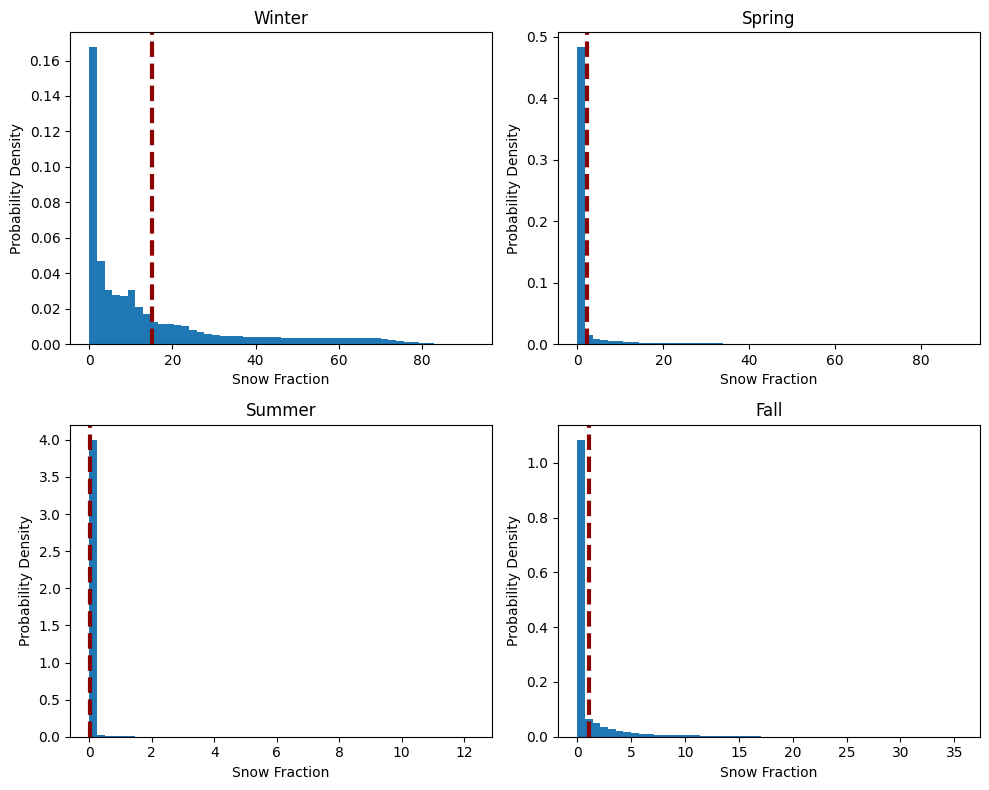

In [25]:
import numpy as np
import matplotlib.pyplot as plt

outputdir = "/Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU"
os.makedirs(outputdir, exist_ok=True)

seasons = ["DJF", "MAM", "JJA", "SON"]
titles = ["Winter", "Spring", "Summer", "Fall"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, season in enumerate(seasons):
    da_season = seasonal.sel(season=season)

    arr = da_season.values.ravel()
    arr = arr[np.isfinite(arr)]

    ax = axes[i]

    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed', linewidth=3, color='darkred')

    ax.set_title(titles[i])
    ax.set_xlabel("Snow Fraction")
    ax.set_ylabel("Probability Density")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_hist_snow_fraction_seasonal.png"), dpi=300)
plt.show()

In [29]:
import xarray as xr
import glob
import pandas as pd
import os

BASE_DIR = "/Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU"

files = sorted(glob.glob(os.path.join(BASE_DIR, "20*/MODSCAG_HBclip_SINU_ALLVARS_20????.nc")))

datasets = []

for fp in files:
    yyyymm = os.path.basename(fp).split("_")[-1].split(".")[0]
    time = pd.to_datetime(yyyymm, format="%Y%m")

    ds = xr.open_dataset(fp)
    ds = ds.assign_coords(time=time).expand_dims("time")

    datasets.append(ds)

ds_all = xr.concat(datasets, dim="time")

print("Time range:", str(ds_all.time.min().values), "to", str(ds_all.time.max().values))
print("Total months:", len(ds_all.time))

Time range: 2016-01-01T00:00:00.000000000 to 2018-12-01T00:00:00.000000000
Total months: 36


In [30]:
import rioxarray
from rasterio.enums import Resampling

# define spatial dims and CRS (sinusoidal)
ds_all = ds_all.rio.set_spatial_dims(x_dim="x", y_dim="y")
ds_all = ds_all.rio.write_crs(
    "+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +a=6371007.181 +b=6371007.181 +units=m +no_defs"
)

# reproject to lat/lon
ds_ll = ds_all.rio.reproject(
    "EPSG:4326",
    resolution=0.0042,
    resampling=Resampling.average
)

print(ds_ll.rio.crs)

EPSG:4326


In [31]:
snow = ds_ll["snow_fraction"]

seasonal = snow.groupby("time.season").mean("time", skipna=True)

print(seasonal)

<xarray.DataArray 'snow_fraction' (season: 4, y: 360, x: 1313)> Size: 8MB
array([[[0.       , 0.       , 0.       , ...,       nan,       nan,
               nan],
        [      nan,       nan, 0.       , ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 1.1619446, 1.1619446,
               nan],
        [      nan,       nan,       nan, ..., 1.2150538, 1.1914144,
         1.1469533]],

       [[0.       , 0.       , 0.       , ...,       nan,       nan,
               nan],
        [      nan,       nan, 0.       , ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
       

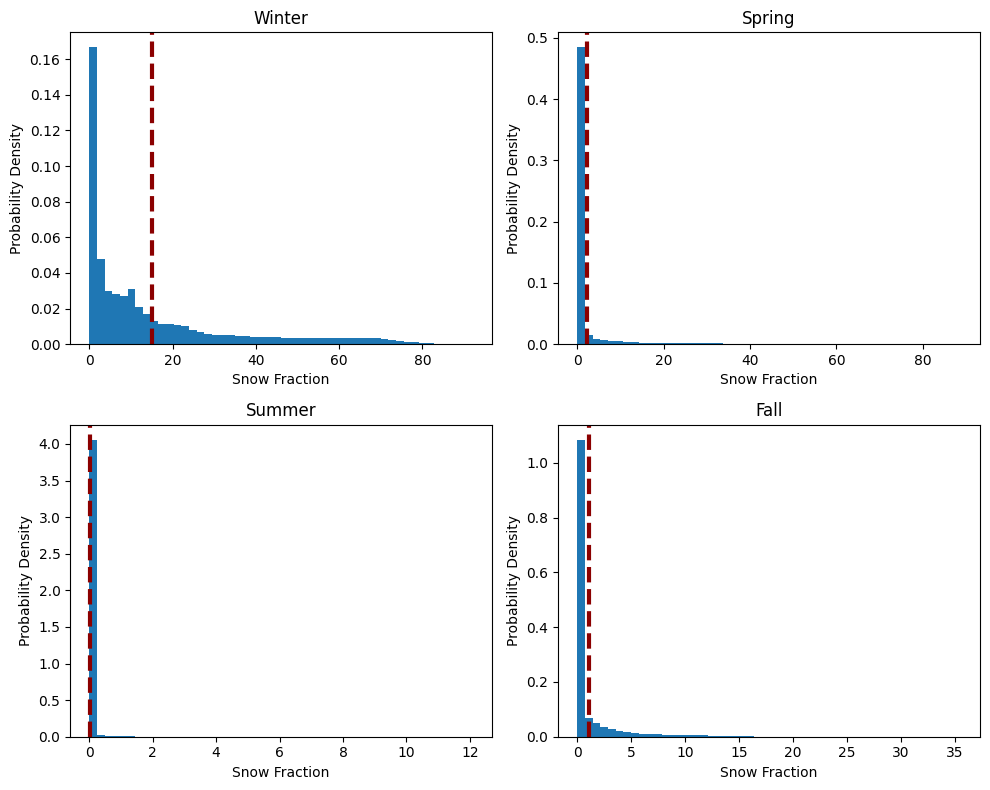

In [33]:
import numpy as np
import matplotlib.pyplot as plt

outputdir = "/Users/bernardnkrumahattobrah/Documents/MODSCAG_SNOW_DATA"
os.makedirs(outputdir, exist_ok=True)

seasons = ["DJF", "MAM", "JJA", "SON"]
titles = ["Winter", "Spring", "Summer", "Fall"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, season in enumerate(seasons):
    da_season = seasonal.sel(season=season)

    arr = da_season.values.ravel()
    arr = arr[np.isfinite(arr)]

    ax = axes[i]

    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed', linewidth=3, color='darkred')

    ax.set_title(titles[i])
    ax.set_xlabel("Snow Fraction")
    ax.set_ylabel("Probability Density")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_hist_snow_fraction_seasonal.png"), dpi=300)
plt.show()